# Part 1: REINFORCE and REINFORCE with baseline for CartPole-v1.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque
import random

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
print(f'Gymnasium version: {gym.__version__}')

Using device: cpu
PyTorch version: 2.11.0
Gymnasium version: 1.2.1


In [3]:
class PolicyNetwork(nn.Module):
    """
    Maps state observations to a probability distribution over actions.
    For CartPole: obs_dim=4, action_dim=2
    """
    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        logits = self.net(x)
        probs  = F.softmax(logits, dim=-1)   # dim=-1 = last dimension = actions
        return probs
    
    def select_action(self, obs: np.ndarray):
        obs_t  = torch.FloatTensor(obs).to(DEVICE)
        probs  = self(obs_t)
        dist   = torch.distributions.Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)


# ── Sanity check ──────────────────────────────────────────────────────────────
env_test   = gym.make('CartPole-v1')
obs_dim    = env_test.observation_space.shape[0]   # 4
action_dim = env_test.action_space.n               # 2
env_test.close()

policy_test = PolicyNetwork(obs_dim, action_dim).to(DEVICE)

# Test with a SINGLE observation
single_obs    = np.zeros(obs_dim)
action, lp    = policy_test.select_action(single_obs)
print(f'obs_dim={obs_dim}, action_dim={action_dim}')
print(f'Single obs → action={action}, log_prob={lp.item():.4f}')

# Test with a BATCH of observations  ← this will expose the bug
batch_obs = torch.FloatTensor(np.random.randn(8, obs_dim)).to(DEVICE)
batch_probs = policy_test(batch_obs)
print(f'\nBatch input shape : {batch_obs.shape}')
print(f'Batch probs shape : {batch_probs.shape}')
print(f'Batch probs sum per row: {batch_probs.sum(dim=-1)}')  # each row must sum to 1.0
print()
print('=== CHECKPOINT ===')
print('Each row of probs must sum to 1.0')
print('If rows do NOT sum to 1.0, find the bug in forward()')

obs_dim=4, action_dim=2
Single obs → action=0, log_prob=-0.7315

Batch input shape : torch.Size([8, 4])
Batch probs shape : torch.Size([8, 2])
Batch probs sum per row: tensor([1., 1., 1., 1., 1., 1., 1., 1.], grad_fn=<SumBackward1>)

=== CHECKPOINT ===
Each row of probs must sum to 1.0
If rows do NOT sum to 1.0, find the bug in forward()


In [5]:
class ValueNetwork(nn.Module):
    """
    Estimates the state-value function V(s).
    Output is a single scalar per observation.
    """
    def __init__(self, obs_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            # nn.Linear(hidden_dim, obs_dim)   # ← look closely at this line
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # squeeze(-1) collapses the last dim: [batch, 1] → [batch]
        return self.net(x).squeeze(-1)


# ── Sanity check ──────────────────────────────────────────────────────────────
value_test = ValueNetwork(obs_dim).to(DEVICE)

# Test 1: single observation
single = torch.FloatTensor(np.zeros(obs_dim)).to(DEVICE)
v_single = value_test(single)
print(f'Single obs input shape  : {single.shape}')
print(f'Single value output shape: {v_single.shape}   ← should be torch.Size([])')

# Test 2: batch of observations
batch = torch.FloatTensor(np.random.randn(8, obs_dim)).to(DEVICE)
v_batch = value_test(batch)
print(f'\nBatch input shape       : {batch.shape}')
print(f'Batch value output shape : {v_batch.shape}   ← should be torch.Size([8])')



Single obs input shape  : torch.Size([4])
Single value output shape: torch.Size([])   ← should be torch.Size([])

Batch input shape       : torch.Size([8, 4])
Batch value output shape : torch.Size([8])   ← should be torch.Size([8])


# Episode Rollout

In [6]:
def collect_episode(env, policy: PolicyNetwork):
    """
    Run the policy for one full episode.

    Returns
    -------
    observations : list of np.ndarray
    actions      : list of int
    rewards      : list of float
    log_probs    : list of torch.Tensor  (each is a scalar, keeps grad)
    """
    observations, actions, rewards, log_probs = [], [], [], []

    obs, _ = env.reset()
    done   = False

    while not done:
        action, log_prob = policy.select_action(obs)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        observations.append(obs)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob)   # keeps the computation graph!

        obs = next_obs

    return observations, actions, rewards, log_probs


# ── Sanity check ──────────────────────────────────────────────────────────────
env_check    = gym.make('CartPole-v1')
policy_check = PolicyNetwork(obs_dim, action_dim).to(DEVICE)

obs_ep, act_ep, rew_ep, lp_ep = collect_episode(env_check, policy_check)
env_check.close()

print(f'Episode length       : {len(rew_ep)} steps')
print(f'Total reward         : {sum(rew_ep)}')
print(f'First log_prob type  : {type(lp_ep[0])}')
print(f'First log_prob value : {lp_ep[0].item():.4f}')
print(f'Has grad             : {lp_ep[0].requires_grad}')


Episode length       : 16 steps
Total reward         : 16.0
First log_prob type  : <class 'torch.Tensor'>
First log_prob value : -0.6501
Has grad             : True


In [8]:
def compute_returns(rewards: list, gamma: float = 0.99) -> torch.Tensor:
    """
    Compute discounted return G_t for each timestep t.

    G_T   = r_T
    G_t   = r_t + gamma * G_{t+1}

    Parameters
    ----------
    rewards : list of floats, length T
    gamma   : discount factor

    Returns
    -------
    returns : torch.Tensor of shape [T]
    """
    T       = len(rewards)
    returns = np.zeros(T)
    G       = 0.0

    # for t in range(T):          # ← look closely at this line
    #     G          = rewards[t] + gamma * G
    #     returns[t] = G

    for t in reversed(range(T)):   # iterate T-1 down to 0
        G          = rewards[t] + gamma * G
        returns[t] = G
        
    return torch.FloatTensor(returns).to(DEVICE)


# ── Sanity check ──────────────────────────────────────────────────────────────
# For rewards = [1, 1, 1] with gamma=0.99, work it out by hand first:
#
#   t=2: G = 1 + 0.99 * 0    = 1.0
#   t=1: G = 1 + 0.99 * 1.0  = 1.99
#   t=0: G = 1 + 0.99 * 1.99 = 2.9701
#
#   So returns should be [2.9701, 1.99, 1.0]

test_rewards = [1.0, 1.0, 1.0]
test_returns = compute_returns(test_rewards, gamma=0.99)

print('Rewards         :', test_rewards)
print('Computed returns:', test_returns.cpu().numpy())

Rewards         : [1.0, 1.0, 1.0]
Computed returns: [2.9701 1.99   1.    ]


# REINFORCE Update (no baseline)

In [10]:
def reinforce_update(policy: PolicyNetwork,
                     optimizer: torch.optim.Optimizer,
                     log_probs: list,
                     returns: torch.Tensor,
                     normalize_returns: bool = True) -> float:
    """
    One REINFORCE gradient update (no baseline).

    Policy gradient theorem:
        ∇J(θ) ∝ Σ_t  G_t * ∇log π(a_t|s_t)

    We maximise J, so we minimise the negative:
        L = -Σ_t  G_t * log π(a_t|s_t)
    """
    if normalize_returns and returns.std() > 1e-8:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    log_probs_t = torch.stack(log_probs)   # list of scalars → Tensor [T]

    # ← look closely at this line
    # policy_loss = (log_probs_t * returns).sum()
    policy_loss = -(log_probs_t * returns).sum() 

    optimizer.zero_grad()
    policy_loss.backward()
    optimizer.step()

    return policy_loss.item()


# ── Sanity check ──────────────────────────────────────────────────────────────
env_c  = gym.make('CartPole-v1')
pol    = PolicyNetwork(obs_dim, action_dim).to(DEVICE)
opt    = torch.optim.Adam(pol.parameters(), lr=1e-3)

# Record params before update
params_before = pol.net[0].weight.data.clone()

_, _, rew_c, lp_c = collect_episode(env_c, pol)
env_c.close()
ret_c = compute_returns(rew_c)

# Run update 20 times and track if policy improves or degrades
returns_over_time = []
env_track = gym.make('CartPole-v1')
for i in range(20):
    o, _, r, lp = collect_episode(env_track, pol)
    ret = compute_returns(r)
    reinforce_update(pol, opt, lp, ret)
    returns_over_time.append(sum(r))

env_track.close()

params_after = pol.net[0].weight.data.clone()

print(f'Params changed         : {not torch.equal(params_before, params_after)}  ← must be True')
print(f'First 5 episode returns: {returns_over_time[:5]}')
print(f'Last  5 episode returns: {returns_over_time[-5:]}')
print(f'Mean first 10          : {np.mean(returns_over_time[:10]):.1f}')
print(f'Mean last  10          : {np.mean(returns_over_time[-10:]):.1f}')


Params changed         : True  ← must be True
First 5 episode returns: [14.0, 23.0, 37.0, 44.0, 13.0]
Last  5 episode returns: [15.0, 47.0, 30.0, 13.0, 15.0]
Mean first 10          : 27.8
Mean last  10          : 21.2


# REINFORCE with Baseline Update

In [14]:
def reinforce_baseline_update(policy: PolicyNetwork,
                               value_net: ValueNetwork,
                               pol_optimizer: torch.optim.Optimizer,
                               val_optimizer: torch.optim.Optimizer,
                               observations: list,
                               log_probs: list,
                               returns: torch.Tensor) -> tuple:

    obs_t  = torch.FloatTensor(np.array(observations)).to(DEVICE)
    values = value_net(obs_t)

    # ── Advantage ──────────────────────────────────────────────────────────
    advantage = returns - values.detach()       # ← .detach() must be HERE

    # ── Actor loss ─────────────────────────────────────────────────────────
    log_probs_t = torch.stack(log_probs)
    actor_loss  = -(log_probs_t * advantage).sum()

    pol_optimizer.zero_grad()
    actor_loss.backward(retain_graph=True)
    pol_optimizer.step()

    # ── Critic loss ────────────────────────────────────────────────────────
    critic_loss = F.mse_loss(values, returns.detach())

    val_optimizer.zero_grad()
    critic_loss.backward()
    val_optimizer.step()

    return actor_loss.item(), critic_loss.item()


# ── Sanity check 
env_c2 = gym.make('CartPole-v1')
pol2   = PolicyNetwork(obs_dim, action_dim).to(DEVICE)
val2   = ValueNetwork(obs_dim).to(DEVICE)
p_opt  = torch.optim.Adam(pol2.parameters(), lr=1e-3)
v_opt  = torch.optim.Adam(val2.parameters(), lr=1e-3)

obs_c2, _, rew_c2, lp_c2 = collect_episode(env_c2, pol2)
env_c2.close()
ret_c2 = compute_returns(rew_c2)

# Check gradient isolation — actor update must NOT touch value network
val_params_before = val2.net[0].weight.data.clone()
pol_params_before = pol2.net[0].weight.data.clone()

a_loss, c_loss = reinforce_baseline_update(
    pol2, val2, p_opt, v_opt, obs_c2, lp_c2, ret_c2
)

val_params_after = val2.net[0].weight.data.clone()
pol_params_after = pol2.net[0].weight.data.clone()

print(f'Actor loss          : {a_loss:.4f}')
print(f'Critic loss         : {c_loss:.4f}')
print()

# Manually check if advantage carries value network gradients
obs_t     = torch.FloatTensor(np.array(obs_c2)).to(DEVICE)
values    = val2(obs_t)
advantage = returns - values  if False else ret_c2 - values
print(f'advantage.requires_grad  : {advantage.requires_grad}')
print(f'advantage grad_fn        : {advantage.grad_fn}')


Actor loss          : 242.8325
Critic loss         : 213.1648

advantage.requires_grad  : True
advantage grad_fn        : <SubBackward0 object at 0x11508eaa0>


In [15]:
# ── Verify the function is fixed ──────────────────────────────────────────────
env_v  = gym.make('CartPole-v1')
pol_v  = PolicyNetwork(obs_dim, action_dim).to(DEVICE)
val_v  = ValueNetwork(obs_dim).to(DEVICE)
p_opt_v = torch.optim.Adam(pol_v.parameters(), lr=1e-3)
v_opt_v = torch.optim.Adam(val_v.parameters(), lr=1e-3)

obs_v, _, rew_v, lp_v = collect_episode(env_v, pol_v)
env_v.close()
ret_v = compute_returns(rew_v)

# Run one update through the function
a_loss, c_loss = reinforce_baseline_update(
    pol_v, val_v, p_opt_v, v_opt_v, obs_v, lp_v, ret_v
)

# Now check advantage INSIDE the function by monkey-patching temporarily
obs_t  = torch.FloatTensor(np.array(obs_v)).to(DEVICE)
values = val_v(obs_t)

advantage_buggy = ret_v - values           # without detach
advantage_fixed = ret_v - values.detach()  # with detach

print(f'Actor loss  : {a_loss:.4f}')
print(f'Critic loss : {c_loss:.4f}')
print()
print(f'Without .detach() → grad_fn: {advantage_buggy.grad_fn}')
print(f'With    .detach() → grad_fn: {advantage_fixed.grad_fn}')
print()
print('=== CHECKPOINT ===')
print('With .detach() → grad_fn must be None')
print('This confirms what your fixed function is doing internally')

Actor loss  : 60.4264
Critic loss : 58.6278

Without .detach() → grad_fn: <SubBackward0 object at 0x116b4e6b0>
With    .detach() → grad_fn: None

=== CHECKPOINT ===
With .detach() → grad_fn must be None
This confirms what your fixed function is doing internally


# Training Loop

In [16]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
GAMMA        = 0.99
LR_POLICY    = 5e-4
LR_VALUE     = 1e-3
HIDDEN_DIM   = 128
NUM_EPISODES = 600
SEEDS        = [42, 123, 7]

def train_reinforce(seed: int, use_baseline: bool = False):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    env   = gym.make('CartPole-v1')
    obs_d = env.observation_space.shape[0]
    act_d = env.action_space.n

    policy  = PolicyNetwork(obs_d, act_d, HIDDEN_DIM).to(DEVICE)
    pol_opt = torch.optim.Adam(policy.parameters(), lr=LR_POLICY)

    if use_baseline:
        value_net = ValueNetwork(obs_d, HIDDEN_DIM).to(DEVICE)
        val_opt   = torch.optim.Adam(value_net.parameters(), lr=LR_VALUE)

    episode_returns = []

    for ep in range(NUM_EPISODES):
        obs_ep, _, rew_ep, lp_ep = collect_episode(env, policy)
        total_return = sum(rew_ep)
        episode_returns.append(total_return)

        returns = compute_returns(rew_ep, gamma=GAMMA)

        if use_baseline:
            reinforce_baseline_update(
                policy, value_net, pol_opt, val_opt,
                obs_ep, lp_ep, returns
            )
        else:
            reinforce_update(policy, pol_opt, lp_ep, returns)

        if (ep + 1) % 100 == 0:
            recent = np.mean(episode_returns[-50:])
            label  = 'w/ baseline' if use_baseline else 'no baseline'
            print(f'  [seed={seed} | {label}] ep {ep+1:4d} '
                  f'avg-50={recent:.1f}')

    env.close()
    return episode_returns


# ── Train both methods ────────────────────────────────────────────────────────
print('='*55)
print('Training REINFORCE (no baseline)...')
print('='*55)
results_plain = []
for s in SEEDS:
    print(f'\n--- Seed {s} ---')
    results_plain.append(train_reinforce(s, use_baseline=False))

print()
print('='*55)
print('Training REINFORCE with baseline...')
print('='*55)
results_baseline = []
for s in SEEDS:
    print(f'\n--- Seed {s} ---')
    results_baseline.append(train_reinforce(s, use_baseline=True))

print()
print('=== CHECKPOINT ===')
print('Both methods trained across 3 seeds.')
print('Baseline avg-50 should climb faster and higher than plain.')

Training REINFORCE (no baseline)...

--- Seed 42 ---
  [seed=42 | no baseline] ep  100 avg-50=29.9
  [seed=42 | no baseline] ep  200 avg-50=51.8
  [seed=42 | no baseline] ep  300 avg-50=166.0
  [seed=42 | no baseline] ep  400 avg-50=225.3
  [seed=42 | no baseline] ep  500 avg-50=313.1
  [seed=42 | no baseline] ep  600 avg-50=278.0

--- Seed 123 ---
  [seed=123 | no baseline] ep  100 avg-50=34.2
  [seed=123 | no baseline] ep  200 avg-50=128.7
  [seed=123 | no baseline] ep  300 avg-50=203.8
  [seed=123 | no baseline] ep  400 avg-50=390.6
  [seed=123 | no baseline] ep  500 avg-50=231.3
  [seed=123 | no baseline] ep  600 avg-50=184.7

--- Seed 7 ---
  [seed=7 | no baseline] ep  100 avg-50=40.2
  [seed=7 | no baseline] ep  200 avg-50=94.7
  [seed=7 | no baseline] ep  300 avg-50=218.8
  [seed=7 | no baseline] ep  400 avg-50=246.7
  [seed=7 | no baseline] ep  500 avg-50=352.2
  [seed=7 | no baseline] ep  600 avg-50=375.9

Training REINFORCE with baseline...

--- Seed 42 ---
  [seed=42 | w/ ba

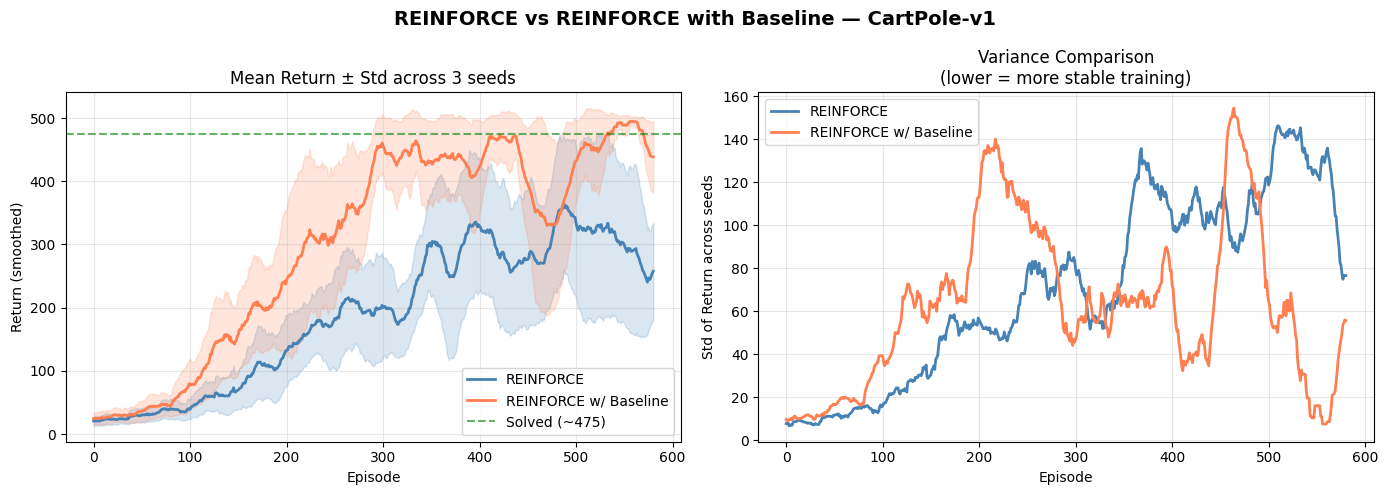

=== Final Performance (last 50 episodes) ===

REINFORCE (no baseline)
  Mean return : 279.5
  Std  return : 129.7
  Peak return : 500

REINFORCE w/ Baseline
  Mean return : 470.4
  Std  return : 66.9
  Peak return : 500


In [17]:
def smooth(data, window=20):
    """Simple moving average."""
    return np.convolve(data, np.ones(window)/window, mode='valid')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('REINFORCE vs REINFORCE with Baseline — CartPole-v1',
             fontsize=14, fontweight='bold')

configs = [
    (results_plain,    'REINFORCE',             'steelblue'),
    (results_baseline, 'REINFORCE w/ Baseline', 'coral'),
]

# ── Left plot: mean return ─────────────────────────────────────────────────
ax = axes[0]
for results, label, color in configs:
    arr  = np.array(results)          # [3 seeds, 600 episodes]
    mean = np.mean(arr, axis=0)
    std  = np.std(arr,  axis=0)
    sm   = smooth(mean)
    ss   = smooth(std)
    xs   = np.arange(len(sm))

    ax.plot(xs, sm, label=label, color=color, lw=2)
    ax.fill_between(xs, sm - ss, sm + ss, alpha=0.2, color=color)

ax.axhline(475, color='green', ls='--', alpha=0.6, label='Solved (~475)')
ax.set_xlabel('Episode')
ax.set_ylabel('Return (smoothed)')
ax.set_title('Mean Return ± Std across 3 seeds')
ax.legend()
ax.grid(alpha=0.3)

# ── Right plot: variance only ──────────────────────────────────────────────
ax2 = axes[1]
for results, label, color in configs:
    arr = np.array(results)
    std = np.std(arr, axis=0)
    xs  = np.arange(len(smooth(std)))
    ax2.plot(xs, smooth(std), label=label, color=color, lw=2)

ax2.set_xlabel('Episode')
ax2.set_ylabel('Std of Return across seeds')
ax2.set_title('Variance Comparison\n(lower = more stable training)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────
print('=== Final Performance (last 50 episodes) ===')
for results, label in [(results_plain, 'REINFORCE (no baseline)'),
                       (results_baseline, 'REINFORCE w/ Baseline')]:
    arr   = np.array(results)
    final = arr[:, -50:]
    print(f'\n{label}')
    print(f'  Mean return : {final.mean():.1f}')
    print(f'  Std  return : {final.std():.1f}')
    print(f'  Peak return : {arr.max():.0f}')

In [18]:
# ── Find best seed from baseline results ─────────────────────────────────────
final_means = [np.mean(r[-50:]) for r in results_baseline]
best_idx    = int(np.argmax(final_means))
best_seed   = SEEDS[best_idx]
print(f'Best seed: {best_seed}  '
      f'(avg last-50 = {final_means[best_idx]:.1f})')

# ── Retrain best seed from scratch ───────────────────────────────────────────
torch.manual_seed(best_seed)
np.random.seed(best_seed)

env_final = gym.make('CartPole-v1')
obs_d     = env_final.observation_space.shape[0]
act_d     = env_final.action_space.n

best_policy = PolicyNetwork(obs_d, act_d, HIDDEN_DIM).to(DEVICE)
best_value  = ValueNetwork(obs_d,  HIDDEN_DIM).to(DEVICE)
bp_opt = torch.optim.Adam(best_policy.parameters(), lr=LR_POLICY)
bv_opt = torch.optim.Adam(best_value.parameters(),  lr=LR_VALUE)

print(f'Retraining seed={best_seed} for {NUM_EPISODES} episodes...')
for ep in range(NUM_EPISODES):
    obs_ep, _, rew_ep, lp_ep = collect_episode(env_final, best_policy)
    ret_ep = compute_returns(rew_ep, GAMMA)
    reinforce_baseline_update(
        best_policy, best_value,
        bp_opt, bv_opt,
        obs_ep, lp_ep, ret_ep
    )
    if (ep + 1) % 200 == 0:
        # Quick eval over 5 episodes
        eval_returns = []
        for _ in range(5):
            _, _, r, _ = collect_episode(env_final, best_policy)
            eval_returns.append(sum(r))
        print(f'  ep {ep+1:4d} | eval avg-5 = {np.mean(eval_returns):.1f}')

env_final.close()

# ── Save ─────────────────────────────────────────────────────────────────────
torch.save({
    'policy_state_dict' : best_policy.state_dict(),
    'value_state_dict'  : best_value.state_dict(),
    'hyperparams': {
        'gamma'      : GAMMA,
        'lr_policy'  : LR_POLICY,
        'lr_value'   : LR_VALUE,
        'hidden_dim' : HIDDEN_DIM,
        'seed'       : best_seed,
        'episodes'   : NUM_EPISODES,
    }
}, 'reinforce_checkpoint.pth')
print('\nCheckpoint saved → reinforce_checkpoint.pth')

# ── Reload and verify ─────────────────────────────────────────────────────────
ckpt = torch.load('reinforce_checkpoint.pth', map_location=DEVICE)
verify_policy = PolicyNetwork(obs_d, act_d, HIDDEN_DIM).to(DEVICE)
verify_policy.load_state_dict(ckpt['policy_state_dict'])
verify_policy.eval()

print('Checkpoint reloaded successfully!')
print(f'Saved hyperparams: {ckpt["hyperparams"]}')



Best seed: 123  (avg last-50 = 486.1)
Retraining seed=123 for 600 episodes...
  ep  200 | eval avg-5 = 233.6
  ep  400 | eval avg-5 = 269.0
  ep  600 | eval avg-5 = 500.0

Checkpoint saved → reinforce_checkpoint.pth
Checkpoint reloaded successfully!
Saved hyperparams: {'gamma': 0.99, 'lr_policy': 0.0005, 'lr_value': 0.001, 'hidden_dim': 128, 'seed': 123, 'episodes': 600}


# Policy Entropy Over Training

In [19]:
def compute_entropy(policy: PolicyNetwork, observations: list) -> float:
    """
    Compute mean policy entropy over a list of observations.
    H(π) = -Σ p(a|s) * log p(a|s)

    High entropy = uncertain/exploring
    Low entropy  = confident/exploiting
    """
    obs_t  = torch.FloatTensor(np.array(observations)).to(DEVICE)
    probs  = policy(obs_t)                        # [T, 2]
    dist   = torch.distributions.Categorical(probs)
    entropy = dist.entropy()                      # [T]
    return entropy.mean().item()


# ── Retrain while tracking entropy ───────────────────────────────────────────
torch.manual_seed(best_seed)
np.random.seed(best_seed)

env_ent = gym.make('CartPole-v1')
obs_d   = env_ent.observation_space.shape[0]
act_d   = env_ent.action_space.n

pol_ent = PolicyNetwork(obs_d, act_d, HIDDEN_DIM).to(DEVICE)
val_ent = ValueNetwork(obs_d,  HIDDEN_DIM).to(DEVICE)
po_opt  = torch.optim.Adam(pol_ent.parameters(), lr=LR_POLICY)
vo_opt  = torch.optim.Adam(val_ent.parameters(), lr=LR_VALUE)

entropy_log  = []
return_log   = []

for ep in range(NUM_EPISODES):
    obs_ep, _, rew_ep, lp_ep = collect_episode(env_ent, pol_ent)
    ret_ep = compute_returns(rew_ep, GAMMA)

    reinforce_baseline_update(
        pol_ent, val_ent,
        po_opt, vo_opt,
        obs_ep, lp_ep, ret_ep
    )

    entropy_log.append(compute_entropy(pol_ent, obs_ep))
    return_log.append(sum(rew_ep))

    if (ep + 1) % 100 == 0:
        print(f'  ep {ep+1:4d} | '
              f'return={return_log[-1]:.0f} | '
              f'entropy={entropy_log[-1]:.4f}')

env_ent.close()

  ep  100 | return=150 | entropy=0.6191
  ep  200 | return=500 | entropy=0.5293
  ep  300 | return=500 | entropy=0.5117
  ep  400 | return=500 | entropy=0.4575
  ep  500 | return=500 | entropy=0.4394
  ep  600 | return=199 | entropy=0.4377


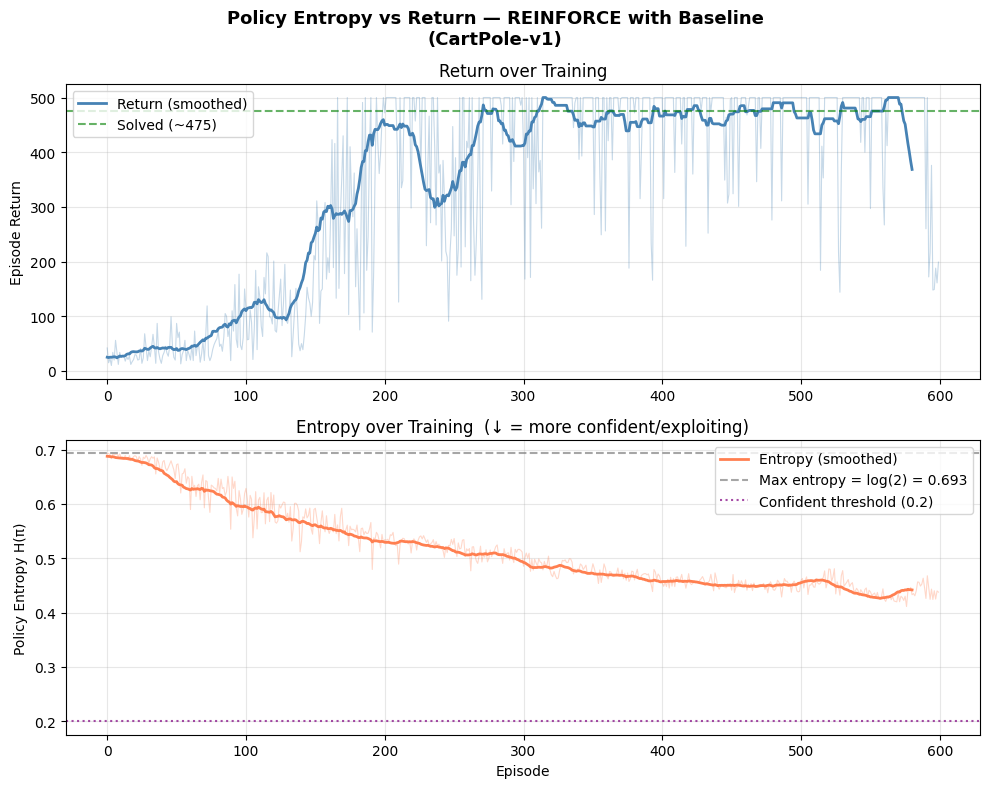

=== Entropy Analysis ===
Theoretical max entropy (2 actions) : 0.6931
Entropy at episode   1              : 0.6928
Entropy at episode 100              : 0.6191
Entropy at episode 300              : 0.5117
Entropy at episode 600              : 0.4377
Total entropy drop                  : 0.2550

Interpretation:
  Exploration phase (ep   0-100) : entropy high, policy still searching
  Transition phase  (ep 100-300) : return rises, entropy starts falling
  Exploitation phase(ep 300-600) : return stable, entropy low and flat


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
fig.suptitle('Policy Entropy vs Return — REINFORCE with Baseline\n(CartPole-v1)',
             fontsize=13, fontweight='bold')

# ── Top: Return ───────────────────────────────────────────────────────────────
ax1 = axes[0]
sm_return = smooth(return_log, window=20)
xs_return = np.arange(len(sm_return))          # ← match length to smoothed array

ax1.plot(np.arange(NUM_EPISODES), return_log,
         color='steelblue', alpha=0.3, lw=0.8)
ax1.plot(xs_return, sm_return,
         color='steelblue', lw=2, label='Return (smoothed)')
ax1.axhline(475, color='green', ls='--', alpha=0.6, label='Solved (~475)')
ax1.set_ylabel('Episode Return')
ax1.set_title('Return over Training')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# ── Bottom: Entropy ───────────────────────────────────────────────────────────
ax2 = axes[1]
sm_entropy = smooth(entropy_log, window=20)
xs_entropy = np.arange(len(sm_entropy))        # ← match length to smoothed array

ax2.plot(np.arange(NUM_EPISODES), entropy_log,
         color='coral', alpha=0.3, lw=0.8)
ax2.plot(xs_entropy, sm_entropy,
         color='coral', lw=2, label='Entropy (smoothed)')
ax2.axhline(np.log(2), color='gray', ls='--', alpha=0.7,
            label=f'Max entropy = log(2) = {np.log(2):.3f}')
ax2.axhline(0.2, color='purple', ls=':', alpha=0.7,
            label='Confident threshold (0.2)')

ax2.set_xlabel('Episode')
ax2.set_ylabel('Policy Entropy H(π)')
ax2.set_title('Entropy over Training  (↓ = more confident/exploiting)')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bonus_b_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Stats ─────────────────────────────────────────────────────────────────────
print('=== Entropy Analysis ===')
print(f'Theoretical max entropy (2 actions) : {np.log(2):.4f}')
print(f'Entropy at episode   1              : {entropy_log[0]:.4f}')
print(f'Entropy at episode 100              : {entropy_log[99]:.4f}')
print(f'Entropy at episode 300              : {entropy_log[299]:.4f}')
print(f'Entropy at episode 600              : {entropy_log[599]:.4f}')
print(f'Total entropy drop                  : {entropy_log[0] - entropy_log[-1]:.4f}')
print()
print('Interpretation:')
print('  Exploration phase (ep   0-100) : entropy high, policy still searching')
print('  Transition phase  (ep 100-300) : return rises, entropy starts falling')
print('  Exploitation phase(ep 300-600) : return stable, entropy low and flat')